# K-Means Clustering Basics

K-Means is an **unsupervised machine learning algorithm** used to **cluster data** into `K` groups based on similarity.

---

## 1. Overview

- **Goal:** Partition `n` data points into `K` clusters.  
- Each cluster has a **centroid** (the mean of points in the cluster).  
- Points are assigned to the cluster with the **nearest centroid**.

---

## 2. Distance Metric

K-Means uses a **distance metric** to measure similarity between points:

- **Euclidean Distance (most common):**
  
  d = sqrt((x1 - x2)^2 + (y1 - y2)^2)

- Other distance options (less common):  
  - Manhattan distance  
  - Cosine distance  

- **Assignment Rule:**  
  Each point is assigned to the cluster whose centroid is **closest**.

---

## 3. Initialization

Proper initialization of centroids is important to avoid **poor convergence**.  

### Methods:

1. **Random Initialization**
   - Pick `K` random points as initial centroids.
   - Simple but may converge to **local minima**.

2. **K-Means++ Initialization**
   - Improves random selection by **spreading out initial centroids**.
   - Reduces the chance of poor clustering.

---

## 4. K-Means Algorithm Steps

1. Initialize `K` centroids (randomly or using K-Means++).  
2. Assign each data point to the **nearest centroid**.  
3. Update centroids by calculating the **mean of points in each cluster**.  
4. Repeat steps 2–3 until **centroids do not change** or max iterations reached.

---

## 5. Notes

- K-Means is sensitive to:
  - **Initialization** → can lead to different clusters each run.
  - **Outliers** → they can shift centroids.
- Always **scale/normalize** features before applying K-Means.

---



### 1. Write a Python function to normalize a dataset using Min–Max scaling (no libraries except NumPy).

In [1]:
import numpy as np
def min_max_scaling(X):
    X = np.array(X,dtype=float)
    min_val = X.min(axis=0)
    max_val = X.max(axis=0)

    ranges = max_val - min_val
    ranges[ranges == 0] = 1
    X_scaled = (X - min_val) / ranges
    return X_scaled

# Example usage
X = np.array([
    [10, 5000],
    [20, 60000],
    [30,70000]
])

scaled_X = min_max_scaling(X)
print(scaled_X)

[[0.         0.        ]
 [0.5        0.84615385]
 [1.         1.        ]]


In [2]:
def min_max_scaling1(X):
    n_features = len(X[0])

    min_vals= []
    max_vals = []
    for i in range(n_features):
        col = [row[i] for row in X if row[i] not in ("",None)]
        min_vals.append(min(col))
        max_vals.append(max(col))

    X_scaled = []
    for row in X:
        scaled_row= []
        for i in range(n_features):
            if row[i] in ("",None):
                scaled_val = None
            else:
                ranges = max_vals[i] - min_vals[i]
                if ranges == 0:
                    ranges = 1
                scaled_val = (row[i] - min_vals[i]) / ranges
            scaled_row.append(scaled_val)
        X_scaled.append(scaled_row)
    return X_scaled
    
X = [
    [10, 5000],
    [20, None],
    ["", 60000],
    [30,66000]
]

scaled_X = min_max_scaling1(X)
print(scaled_X) 


[[0.0, 0.0], [0.5, None], [None, 0.9016393442622951], [1.0, 1.0]]


### 2. Write a function euclidean_distance(x1, x2) that returns the Euclidean distance between two data points.

In [3]:
def euclidean_distance(x1,x2):
    dis = sum((a-b)**2 for a,b in zip(x1,x2)) **0.5
    return dis
# Test with 2D points 
p1 =[19.0, 19000.0]
p2= [35.0, 20000.0]
dis = euclidean_distance(p1,p2)
print("The Euclidean distance between two points is ",dis)

The Euclidean distance between two points is  1000.1279918090484


### 3. Randomly initialize K centroids from your dataset and print their values.

In [4]:
import random

def randomly_initialize(X, K):
    if K > len(X):
        raise ValueError("K cannot be greater than number of data points")
    return random.sample(X, K)

X = [
    [1, 2],
    [1.5, 1.8],
    [5, 8],
    [8, 8],
    [1, 0.6],
    [9, 11]
]

K = 2
centroids = randomly_initialize(X, K)
print("Centroids are:", centroids)


Centroids are: [[1.5, 1.8], [8, 8]]


### 4. Assign each data point to the nearest centroid using your distance function and return the cluster labels.

In [5]:

def assign_clusters(X, centroids):
    labels = []

    for point in X:
        distances = []

        for centroid in centroids:
            dist = euclidean_distance(point, centroid)
            distances.append(dist)

        # index of minimum distance → cluster label
        cluster_label = distances.index(min(distances))
        labels.append(cluster_label)

    return labels


X = [
    [1, 2],
    [1.5, 1.8],
    [5, 8],
    [8, 8],
    [1, 0.6],
    [9, 11]
]

K = 2
centroids = randomly_initialize(X, K)
labels = assign_clusters(X,centroids)
print(labels)

[1, 1, 1, 1, 0, 1]


### 5. Modify your code so it supports any value of K dynamically (K ≥ 2).

In [6]:
import random
import math

#  Min-Max scaling with missing values 
def min_max_scaling1(X):
    n_features = len(X[0])

    min_vals = []
    max_vals = []
    for i in range(n_features):
        # only consider non-missing values
        col = [row[i] for row in X if row[i] not in ("", None)]
        min_vals.append(min(col) if col else 0)  # default 0 if all missing
        max_vals.append(max(col) if col else 1)  # default 1 if all missing

    X_scaled = []
    for row in X:
        scaled_row = []
        for i in range(n_features):
            if row[i] in ("", None):
                scaled_val = None
            else:
                ranges = max_vals[i] - min_vals[i]
                if ranges == 0:
                    ranges = 1
                scaled_val = (row[i] - min_vals[i]) / ranges
            scaled_row.append(scaled_val)
        X_scaled.append(scaled_row)
    return X_scaled

#  Euclidean distance that ignores missing features 
def euclidean_distance(x1, x2):
    dist = 0
    count = 0
    for a, b in zip(x1, x2):
        if a is not None and b is not None:
            dist += (a - b) ** 2
            count += 1
    # if all features missing, return a large distance
    if count == 0:
        return float('inf')
    return math.sqrt(dist)

#  Randomly initialize centroids 
def randomly_initialize(X, K):
    if K > len(X):
        raise ValueError("K cannot be greater than number of data points")
    if K < 2:
        raise ValueError("K must be greater than or equal to 2")
    return random.sample(X, K)

#  Assign clusters 
def assign_clusters(X, centroids):
    labels = []
    for point in X:
        distances = []
        for centroid in centroids:
            dist = euclidean_distance(point, centroid)
            distances.append(dist)
        cluster_label = distances.index(min(distances))
        labels.append(cluster_label)
    return labels

#  Example data with missing values 
X = [
    [1, 10000],
    [1.5, None],
    [5, 15000],
    [8, 20000],
    ["", 22000],
    [9, 15000]
]

K = 2

scaled_X = min_max_scaling1(X)
print("Scaled_X:", scaled_X)

centroids = randomly_initialize(scaled_X, K)
print("Centroids:", centroids)

labels = assign_clusters(scaled_X, centroids)
print("Cluster labels:", labels)


Scaled_X: [[0.0, 0.0], [0.0625, None], [0.5, 0.4166666666666667], [0.875, 0.8333333333333334], [None, 1.0], [1.0, 0.4166666666666667]]
Centroids: [[0.5, 0.4166666666666667], [None, 1.0]]
Cluster labels: [0, 0, 0, 1, 1, 0]


### 6. Plot the dataset and show centroid positions before clustering starts (without sklearn).

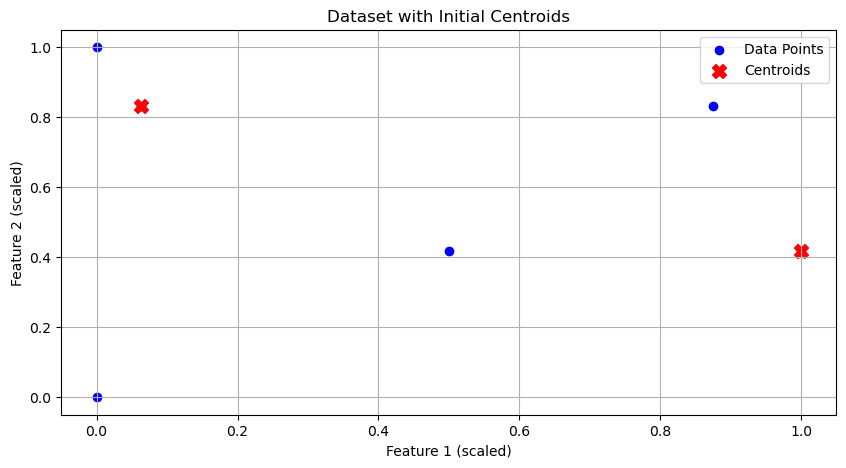

In [7]:

import matplotlib.pyplot as plt
# Example data (with no missing values for simplicity in plotting)
X = [
    [1, 10000],
    [1.5, 20000],
    [5, 15000],
    [8, 20000],
    [1, 22000],
    [9, 15000]
]

K = 2

#  Scale X and initialize centroids 
scaled_X = min_max_scaling1(X)
centroids = randomly_initialize(scaled_X, K)
 
# Separate X and Y for plotting
x_vals = [point[0] for point in scaled_X]
y_vals = [point[1] for point in scaled_X]

cent_x = [c[0] for c in centroids]
cent_y = [c[1] for c in centroids]

plt.figure(figsize=(10, 5))
plt.scatter(x_vals, y_vals, color='blue', label='Data Points')
plt.scatter(cent_x, cent_y, color='red', marker='X', s=100, label='Centroids')

plt.title("Dataset with Initial Centroids")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.legend()
plt.grid(True)
plt.show()




### K-Means — Iterations & Convergence

### 1. Write a function that updates centroids by calculating the mean of assigned points.

In [8]:
def update_centroids(X, labels, K):
    
    n_features = len(X[0])
    new_centroids = []

    for k in range(K):
        cluster_points = [X[i] for i in range(len(X)) if labels[i] == k]

        centroid = []
        for f in range(n_features):
            # take only non-missing values
            values = [p[f] for p in cluster_points if p[f] is not None]
            if values:
                mean_val = sum(values) / len(values)
            else:
                mean_val = None  # if all missing
            centroid.append(mean_val)
        new_centroids.append(centroid)
    
    return new_centroids
X = [
    [1, 10000],
    [1.5, 20000],
    [5, 15000],
    [8, 20000],
    [1, 22000],
    [9, 15000]
]

K = 2
scaled_X = min_max_scaling1(X)
centroids = randomly_initialize(scaled_X, K)
labels = assign_clusters(scaled_X, centroids)
print("labels: ", labels)
print("Old centroids:", centroids)

new_centroids = update_centroids(scaled_X, labels, K)
print("Updated centroids:", new_centroids)

labels:  [1, 1, 1, 0, 1, 0]
Old centroids: [[0.875, 0.8333333333333334], [0.5, 0.4166666666666667]]
Updated centroids: [[0.9375, 0.625], [0.140625, 0.5625]]


### 2. Create a loop that:
```
• assigns clusters
• updates centroids
• repeats until stable

In [9]:
import random

def kmeans(X, K, max_iters=100, tol=1e-4):
   
    # 1. Initialize centroids randomly
    centroids = randomly_initialize(X, K)
    
    for iteration in range(max_iters):
        # 2. Assign clusters
        labels = assign_clusters(X, centroids)
        
        # 3. Update centroids
        new_centroids = update_centroids(X, labels, K)
        
        # 4. Check if centroids have changed (convergence)
        stable = True
        for c_old, c_new in zip(centroids, new_centroids):
            # compute Euclidean distance between old and new centroid
            dist = euclidean_distance(c_old, c_new)
            if dist > tol:
                stable = False
                break
        
        centroids = new_centroids
        
        if stable:
            print(f"Converged after {iteration+1} iterations")
            break
    
    return centroids, labels


X = [
    [1, 10000],
    [1.5, 20000],
    [5, 15000],
    [8, 20000],
    [1, 22000],
    [9, 15000]
]

K = 2

# Scale data first
scaled_X = min_max_scaling1(X)

# Run K-Means
final_centroids, final_labels = kmeans(scaled_X, K)

print("Final Centroids:", final_centroids)
print("Cluster Labels:", final_labels)


Converged after 2 iterations
Final Centroids: [[0.020833333333333332, 0.6111111111111112], [0.7916666666666666, 0.5555555555555556]]
Cluster Labels: [0, 0, 1, 1, 0, 1]


### 3. Stop training when centroid movement is less than a small tolerance (e.g., 1e-4).

In [10]:
import random

def kmeans(X, K, max_iters=100, tol=1e-4):
   
    # 1. Initialize centroids randomly
    centroids = randomly_initialize(X, K)
    
    for iteration in range(max_iters):
        # 2. Assign clusters
        labels = assign_clusters(X, centroids)
        
        # 3. Update centroids
        new_centroids = update_centroids(X, labels, K)
        
        # 4. Check if centroids have changed (convergence)
        stable = True
        for c_old, c_new in zip(centroids, new_centroids):
            # compute Euclidean distance between old and new centroid
            dist = euclidean_distance(c_old, c_new)
            if dist > tol:
                stable = False
                break
        
        centroids = new_centroids
    
    return centroids, labels


X = [
    [1, 10000],
    [1.5, 20000],
    [5, 15000],
    [8, 20000],
    [1, 22000],
    [9, 15000]
]

K = 2

# Scale data first
scaled_X = min_max_scaling1(X)

# Run K-Means
final_centroids, final_labels = kmeans(scaled_X, K)

print("Final Centroids:", final_centroids)
print("Cluster Labels:", final_labels)


Final Centroids: [[0.59375, 0.4166666666666667], [0.03125, 0.9166666666666667]]
Cluster Labels: [0, 1, 0, 0, 1, 0]


### 4. Print the number of iterations taken to converge.

In [11]:
import random

def kmeans(X, K, max_iters=100, tol=1e-4):
   
    # 1. Initialize centroids randomly
    centroids = randomly_initialize(X, K)
    
    for iteration in range(max_iters):
        # 2. Assign clusters
        labels = assign_clusters(X, centroids)
        
        # 3. Update centroids
        new_centroids = update_centroids(X, labels, K)
        
        # 4. Check if centroids have changed (convergence)
        stable = True
        for c_old, c_new in zip(centroids, new_centroids):
            # compute Euclidean distance between old and new centroid
            dist = euclidean_distance(c_old, c_new)
            if dist > tol:
                stable = False
                break
        
        centroids = new_centroids
        # only this 3 line is new from the above one
        if stable:
            print(f"Converged after {iteration+1} iterations")
            break
    
    return centroids, labels


X = [
    [1, 10000],
    [1.5, 20000],
    [5, 15000],
    [8, 20000],
    [1, 22000],
    [9, 15000]
]

K = 2

# Scale data first
scaled_X = min_max_scaling1(X)

# Run K-Means
final_centroids, final_labels = kmeans(scaled_X, K)

print("Final Centroids:", final_centroids)
print("Cluster Labels:", final_labels)


Converged after 3 iterations
Final Centroids: [[0.59375, 0.4166666666666667], [0.03125, 0.9166666666666667]]
Cluster Labels: [0, 1, 0, 0, 1, 0]


### 5. Compute WCSS (Within Cluster Sum of Squares) manually for your final clusters.

In [26]:
import random
import math

# Min-Max Scaling
def min_max_scaling1(X):
    n_features = len(X[0])

    min_vals = []
    max_vals = []

    for i in range(n_features):
        col = [row[i] for row in X if row[i] not in ("", None)]
        min_vals.append(min(col))
        max_vals.append(max(col))

    X_scaled = []
    for row in X:
        scaled_row = []
        for i in range(n_features):
            if row[i] in ("", None):
                scaled_val = None
            else:
                range_val = max_vals[i] - min_vals[i]
                if range_val == 0:
                    range_val = 1
                scaled_val = (row[i] - min_vals[i]) / range_val
            scaled_row.append(scaled_val)
        X_scaled.append(scaled_row)

    return X_scaled


# Euclidean Distance
def euclidean_distance(x1, x2):
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(x1, x2)))


# Random Centroid Initialization
def randomly_initialize(X, K):
    if K < 2:
        raise ValueError("K must be >= 2")
    if K > len(X):
        raise ValueError("K cannot exceed number of data points")
    return random.sample(X, K)


# Assign Clusters
def assign_clusters(X, centroids):
    labels = []

    for point in X:
        distances = []
        for centroid in centroids:
            distances.append(euclidean_distance(point, centroid))
        labels.append(distances.index(min(distances)))

    return labels



# Update Centroids
def update_centroids(X, labels, K):
    n_features = len(X[0])
    new_centroids = []

    for k in range(K):
        cluster_points = [X[i] for i in range(len(X)) if labels[i] == k]

        centroid = []
        for f in range(n_features):
            values = [p[f] for p in cluster_points if p[f] is not None]
            if values:
                centroid.append(sum(values) / len(values))
            else:
                centroid.append(None)

        new_centroids.append(centroid)

    return new_centroids


# K-Means Algorithm
def kmeans(X, K, max_iters=100, tol=1e-4):
    centroids = randomly_initialize(X, K)

    for iteration in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, K)

        stable = True
        for old, new in zip(centroids, new_centroids):
            if euclidean_distance(old, new) > tol:
                stable = False
                break

        centroids = new_centroids

        if stable:
            print(f"Converged after {iteration + 1} iterations")
            break

    return centroids, labels, iteration + 1

# Compute WCSS

def compute_wcss(X, labels, centroids):
    wcss = 0.0
    for i in range(len(X)):
        centroid = centroids[labels[i]]
        dist = euclidean_distance(X[i], centroid)
        wcss += dist ** 2
    return wcss

X = [
    [1, 10000],
    [1.5, 20000],
    [5, 15000],
    [8, 20000],
    [1, 22000],
    [9, 15000]
]

K = 2

# Scale data
scaled_X = min_max_scaling1(X)

# Run K-Means
final_centroids, final_labels, iterations = kmeans(scaled_X, K)

# Compute WCSS
wcss = compute_wcss(scaled_X, final_labels, final_centroids)

# Output
print("\nFinal Centroids:", final_centroids)
print("Cluster Labels:", final_labels)
print("Iterations Taken:", iterations)
print("WCSS:", wcss)


Converged after 2 iterations

Final Centroids: [[0.140625, 0.5625], [0.9375, 0.625]]
Cluster Labels: [0, 0, 0, 1, 0, 1]
Iterations Taken: 2
WCSS: 0.871853298611111


### 6. Implement the Elbow Method without sklearn and print the best K.

Converged after 2 iterations
K=2, WCSS=1.1174, Iterations=2
Converged after 2 iterations
K=3, WCSS=0.3223, Iterations=2
Converged after 2 iterations
K=4, WCSS=0.2512, Iterations=2
Converged after 2 iterations
K=5, WCSS=0.0158, Iterations=2
Converged after 1 iterations
K=6, WCSS=0.0000, Iterations=1


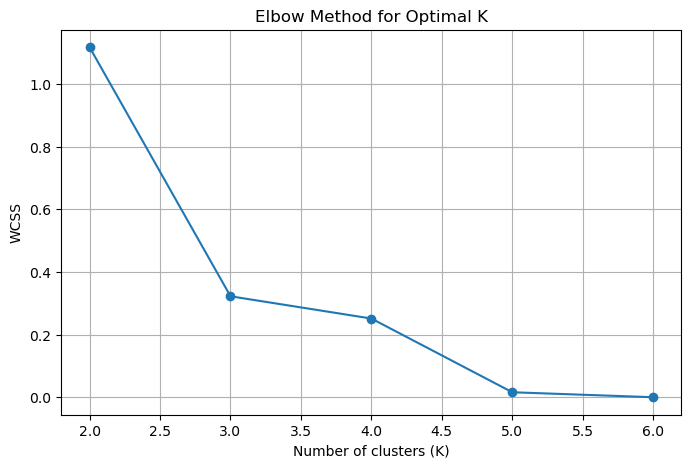

Suggested best K (visual elbow): 2


In [33]:
import matplotlib.pyplot as plt

# Range of K to test
K_values = list(range(2, 7))
wcss_values = []

# Scale your dataset first
scaled_X = min_max_scaling1(X)

# Run K-Means for each K
for K in K_values:
    centroids, labels, iterations = kmeans(scaled_X, K)
    wcss = compute_wcss(scaled_X, labels, centroids)
    wcss_values.append(wcss)
    print(f"K={K}, WCSS={wcss:.4f}, Iterations={iterations}")

# Plot the Elbow
plt.figure(figsize=(8, 5))
plt.plot(K_values, wcss_values, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

best_K = 2
print("Suggested best K (visual elbow):", best_K)


In [45]:
import matplotlib.pyplot as plt
K_values = range(2,7)
scaled_x = min_max_scaling1(X)
wcss = []
for K in K_values:
    centroids,labels,iterations = kmeans(scaled_x, K,tol=1e-4)
    val = compute_wcss(scaled_x,labels,centroids)
    wcss.append(val)
    print(f"K={K}, wcss = {val:.4f}, iteration = {iterations} ")

def drops_best_k(K_values,wcss):
    drops = []
    for i in range(1,len(wcss)):
        drop = [wcss[i-1] - wcss[i]]
        drops.append(drop)
    max_drop_index = drops.index(max(drops))
    best_k = K_values[max_drop_index]

    return best_k, drops
    
best_k, drops = drops_best_k(K_values, wcss_values)

print("WCSS drops:", drops)
print("Best K (largest drop method):", best_k)   

Converged after 2 iterations
K=2, wcss = 0.9685, iteration = 2 
Converged after 2 iterations
K=3, wcss = 0.7017, iteration = 2 
Converged after 2 iterations
K=4, wcss = 0.2512, iteration = 2 
Converged after 2 iterations
K=5, wcss = 0.2118, iteration = 2 
Converged after 1 iterations
K=6, wcss = 0.0000, iteration = 1 
WCSS drops: [[0.795095486111111], [0.07110821759259262], [0.23531539351851855], [0.015842013888888885]]
Best K (largest drop method): 2
